Dane + opis

1. EDA

Przygotowanie bibliotek:
pip install pandas
pip install matplotlib
pip install seaborn
pip install numpy
pip install -U scikit-learn
pip install xgboost

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Załadowanie zbioru danych
df = pd.read_csv('aac_shelter_outcomes.csv')

# Zamiana zmiennej 'outcome' na problem binarny: 1 dla Adoption, 0 dla reszty
df['is_adopted'] = (df['outcome_type'] == 'Adoption').astype(int)

# Sprawdzenie rozkładu klas
class_counts = df['is_adopted'].value_counts()
class_props = df['is_adopted'].value_counts(normalize=True) * 100

print("--- Rozkład klas (Adoptowane vs Inne) ---")
print(f"Adoptowane (1): {class_counts[1]} ({class_props[1]:.2f}%)")
print(f"Inne (0): {class_counts[0]} ({class_props[0]:.2f}%)")

# Wykres 1: Rozkład klas
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='is_adopted', hue='is_adopted', data=df, palette='Set2', legend=False)
plt.title('Rozkład klas docelowych: Adopcja (1) vs Inne (0)')
plt.xlabel('Został adoptowany (1 = Tak, 0 = Nie)')
plt.ylabel('Liczba zwierząt')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.savefig('rozkad_klas.png', bbox_inches='tight')
plt.close()

# 2. Rodzaj zwierzęcia (Dog vs Cat) a wpływ na adopcje
print("\n--- Analiza typu zwierzęcia (Pies vs Kot) ---")

# Filtr dla psów i kotów
df_dogs_cats = df[df['animal_type'].isin(['Dog', 'Cat'])]
print(df_dogs_cats['animal_type'].value_counts())

# Wykres 2: Szansa na adopcję psów i kotów
plt.figure(figsize=(8, 5))
ax2 = sns.barplot(x='animal_type', y='is_adopted', hue='animal_type', data=df_dogs_cats, palette='Pastel1', errorbar=None, legend=False)
plt.title('Szansa na adopcję: Pies vs Kot')
plt.xlabel('Typ zwierzęcia')
plt.ylabel('Prawdopodobieństwo adopcji')
plt.ylim(0, 1)

# Podpis z procentami
for p in ax2.patches:
    ax2.annotate(f'{p.get_height()*100:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='center', xytext=(0, 8), textcoords='offset points')
plt.savefig('szansa_adopcji_pies_kot.png', bbox_inches='tight')
plt.close()

# Wykres 3: Liczba zwierząt: Pies vs Kot z podziałem na wynik
plt.figure(figsize=(8, 5))
ax3 = sns.countplot(x='animal_type', hue='is_adopted', data=df_dogs_cats, palette='Set2')
plt.title('Liczba zwierząt: Pies vs Kot z podziałem na wynik')
plt.xlabel('Typ zwierzęcia')
plt.ylabel('Liczba zwierząt')
plt.legend(title='Adopcja (1=Tak, 0=Nie)')
plt.savefig('liczba_pies_kot_wynik.png', bbox_inches='tight')
plt.close()

--- Rozkład klas (Adoptowane vs Inne) ---
Adoptowane (1): 33112 (42.31%)
Inne (0): 45144 (57.69%)

--- Analiza typu zwierzęcia (Pies vs Kot) ---
animal_type
Dog    44242
Cat    29422
Name: count, dtype: int64


2. Preprocessing + pipeline

(wymóg zadania) - dodajemy cechę losową, która nie powinna mieć wpływu na wynik, ale pozwoli nam sprawdzić, czy model jest w stanie ją zignorować

In [ ]:
import numpy as np
import re
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# 1. Funkcja do konwersji wieku na dni
def convert_age_to_days(age_str):
    if pd.isna(age_str):
        return np.nan
    
    # Szukanie liczby i jednostki
    match = re.search(r'(\d+)\s+([a-zA-Z]+)', str(age_str))
    if not match:
        return np.nan
        
    num = int(match.group(1))
    unit = match.group(2).lower()
    
    if 'year' in unit:
        return num * 365
    elif 'month' in unit:
        return num * 30
    elif 'week' in unit:
        return num * 7
    elif 'day' in unit:
        return num
    else:
        return np.nan


# Aplikujemy funkcję do kolumny 'age_upon_outcome' i tworzymy nową kolumnę 'age_in_days'
df['age_in_days'] = df['age_upon_outcome'].apply(convert_age_to_days)

# Zmienna losowa do Sanity Check! 
np.random.seed(42)
df['random_feature'] = np.random.uniform(0, 1, size=len(df))

# 2. Definiuja cech do modelu
# Zmniejszamy kardynalność - bierzemy tylko podstawowe cechy na start 
features_num = ['age_in_days', 'random_feature']
features_cat = ['animal_type', 'sex_upon_outcome'] 

# Odfiltrowujemy braki w zmiennej docelowej (jeśli jakieś są) - to ważne, bo modele nie mogą trenować na brakach w targetcie!
df = df.dropna(subset=['is_adopted'])

X = df[features_num + features_cat]
y = df['is_adopted']

# Podział na zbiór treningowy i testowy (STRATIFY jest tu kluczowe!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Budowa Pipeline'u
# Transformer dla danych numerycznych (uzupełnianie braków medianą i skalowanie)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Transformer dla danych kategorialnych (uzupełnianie braków wartością najczęstszą i One-Hot Encoding)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Połączenie transformerów w jeden preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, features_num),
        ('cat', categorical_transformer, features_cat)
    ])

print("Dane przygotowane, Pipeline preprocessingowy gotowy do podpięcia pod modele!")

Dane przygotowane, Pipeline preprocessingowy gotowy do podpięcia pod modele!


3. Przygotowanie i trenowanie modeli AI 

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb 

# --- KROK 3: INICJALIZACJA I TRENOWANIE MODELI ---

print("Rozpoczynam trenowanie modeli...")

# 1. Model "White-box" (Interpretowalny z natury) - Regresja Logistyczna
# Używamy max_iter=1000, aby algorytm miał czas na zbiegnięcie się
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor), # preprocessor z poprzedniego kroku
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

# Trenowanie modelu
pipeline_lr.fit(X_train, y_train)
print("1. Regresja Logistyczna wytrenowana.")


# 2. Model "Black-box" (Złożony 1) - Las Losowy (Random Forest)
# Ograniczamy max_depth do np. 10, aby model nie przeuczył się drastycznie na danych testowych
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced', n_jobs=-1))
])

# Trenowanie modelu
pipeline_rf.fit(X_train, y_train)
print("2. Random Forest wytrenowany.")


# 3. Model "Black-box" (Złożony 2) - XGBoost (Gradient Boosting)
# XGBoost to jeden z najpotężniejszych modeli dla danych tabelarycznych, 
# świetnie współpracuje później z TreeSHAP.
pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, eval_metric='logloss'))
])

# Trenowanie modelu
pipeline_xgb.fit(X_train, y_train)
print("3. XGBoost wytrenowany.")

print("Wszystkie modele są gotowe do ewaluacji!")

Rozpoczynam trenowanie modeli...
1. Regresja Logistyczna wytrenowana.
2. Random Forest wytrenowany.
3. XGBoost wytrenowany.
Wszystkie modele są gotowe do ewaluacji!


4. Ocena jakości modeli

a. Metryki i Krzywe ROC
Ten fragment wyliczy Precision, Recall, F1-Score dla każdego modelu i narysuje połączony wykres ROC AUC, który świetnie będzie wyglądał w raporcie.

--- OCENA MODELI NA ZBIORZE TESTOWYM ---

[Regresja Logistyczna] Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.88      0.64      0.74      9029
           1       0.64      0.88      0.74      6623

    accuracy                           0.74     15652
   macro avg       0.76      0.76      0.74     15652
weighted avg       0.78      0.74      0.74     15652

[Regresja Logistyczna] ROC AUC: 0.8406

[Random Forest] Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.84      0.72      0.78      9029
           1       0.68      0.81      0.74      6623

    accuracy                           0.76     15652
   macro avg       0.76      0.77      0.76     15652
weighted avg       0.77      0.76      0.76     15652

[Random Forest] ROC AUC: 0.8596

[XGBoost] Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.78      0.82      0.80      9029
          

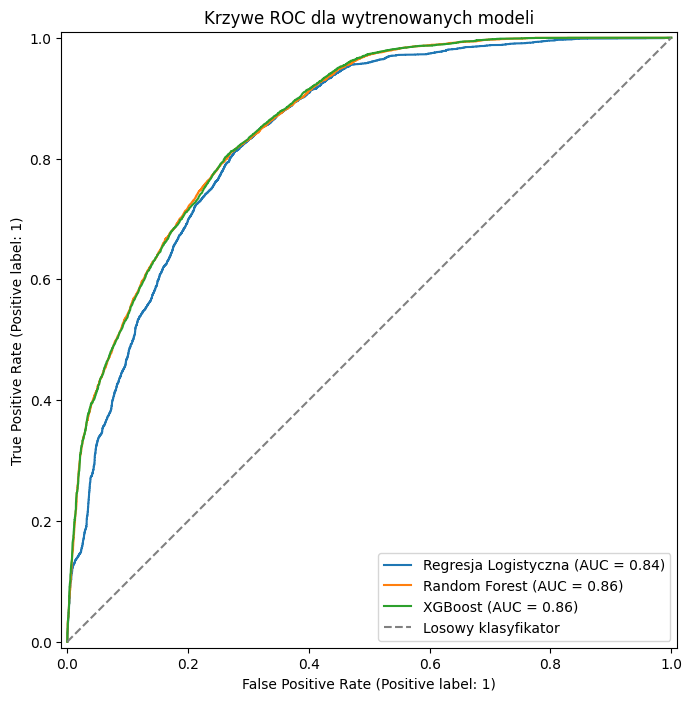

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay

print("--- OCENA MODELI NA ZBIORZE TESTOWYM ---")

modele = {
    "Regresja Logistyczna": pipeline_lr,
    "Random Forest": pipeline_rf,
    "XGBoost": pipeline_xgb
}

fig, ax = plt.subplots(figsize=(10, 8))

for nazwa, model in modele.items():
    # 1. Predykcje
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # 2. Raport klasyfikacji
    print(f"\n[{nazwa}] Raport klasyfikacji:")
    print(classification_report(y_test, y_pred))
    
    # 3. ROC AUC Score
    auc_score = roc_auc_score(y_test, y_pred_proba)
    print(f"[{nazwa}] ROC AUC: {auc_score:.4f}")
    
    # 4. Rysowanie krzywej ROC na wspólnym wykresie
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=nazwa, ax=ax)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Losowy klasyfikator')
ax.set_title('Krzywe ROC dla wytrenowanych modeli')
plt.legend()
plt.savefig('krzywe_roc.png', bbox_inches='tight')
plt.show()

b. Krzywe Uczenia (Learning Curves)
Prowadzący kładzie nacisk na poprawne podstawy ML. Krzywe uczenia udowodnią, że modele są stabilne. Użyjemy tu walidacji krzyżowej (StratifiedKFold).

Generowanie krzywej uczenia dla XGBoost (to może potrwać chwile)...


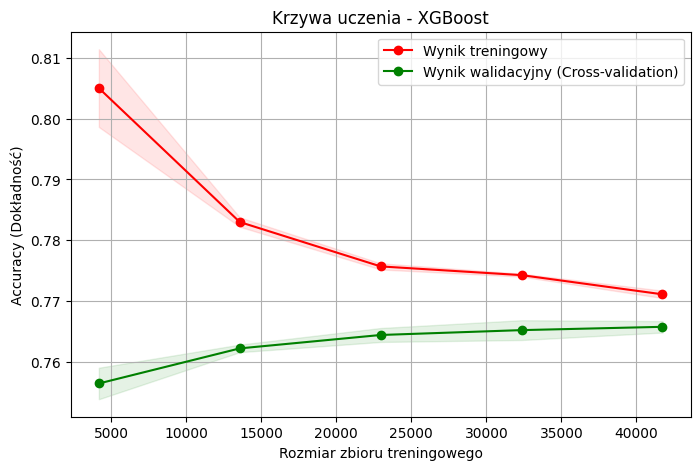

In [10]:
from sklearn.model_selection import learning_curve, StratifiedKFold
import numpy as np

def plot_learning_curve(estimator, title, X, y, cv=3):
    plt.figure(figsize=(8, 5))
    plt.title(title)
    plt.xlabel("Rozmiar zbioru treningowego")
    plt.ylabel("Accuracy (Dokładność)")
    
    # Obliczanie krzywych uczenia
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy'
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.grid()
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Wynik treningowy")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Wynik walidacyjny (Cross-validation)")
    
    plt.legend(loc="best")
    plt.show()

# Generujemy krzywą uczenia dla najciekawszego modelu - XGBoost
print("Generowanie krzywej uczenia dla XGBoost (to może potrwać chwile)...")
cv_fold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
plot_learning_curve(pipeline_xgb, "Krzywa uczenia - XGBoost", X_train, y_train, cv=cv_fold)